In [1]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./funlopt/funl_dynamics.jl")
include("./funlopt/funl_utils.jl")
include("./funlopt/funl_constraint.jl")
include("./trajopt/scaling.jl")

compute_scaling (generic function with 1 method)

In [2]:
# load nominal trajectory
using JLD2, FileIO
filename = "./data/traj_result" 
@load filename my_dict
xnom = my_dict["x"]
unom = my_dict["u"]
tnom = my_dict["t"];
N = size(xnom,2) - 1
dtnom = zeros(N)
for i in 1:N
    dtnom[i] = tnom[i+1]-tnom[i]
end

In [3]:
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
push!(c_list, [4.0, 2.5])
push!(H_list, get_H_obs(1.5, 4.0))

vmax = 2.0
vmin = 0.0
wmax = 1.5
wmin = -1.5
list_const = Vector{FunnelConstraint}()
push!(list_const,InputConstraint([1;0],vmax))
push!(list_const,InputConstraint([-1;0],-vmin))
push!(list_const,InputConstraint([0; 1],wmax))
push!(list_const,InputConstraint([0; -1],-wmin))
for i = 1:length(c_list)
    push!(list_const,ObstacleAvoidance(H_list[i],c_list[i]))
end

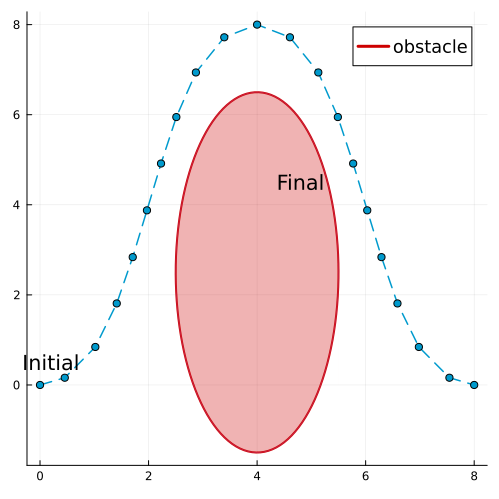

In [4]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
scatter!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linewidth=1.5,label=nothing)
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
annotate!(0.2, 0.5, text("Initial", :black, :center))
annotate!(4.8, 4.5, text("Final", :black, :center))
display(p2)

In [5]:
ix = 3
iu = 2
iw = 2
dynamics = Unicycle()

Unicycle(3, 2, 2, 6, 2, 12, 8, 6, 8, [0.0 0.0 1.0; 0.0 0.0 0.0; … ; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; … ; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; … ; 0.0 0.0; 1.0 0.0], 0.03, 0.05, #undef, #undef, #undef, #undef)

In [6]:
A = zeros(ix,ix,N+1)
B = zeros(ix,iu,N+1)
F = zeros(ix,iw,N+1)
for idx in 1:N+1
    A[:,:,idx],B[:,:,idx],F[:,:,idx] = diff_ABF(dynamics,xnom[:,idx],unom[:,idx])
end

In [7]:
Qmax = zeros(ix,ix,N+1)
for idx in 1:N+1
    Qmax[:,:,idx] .= diagm([2^2,2^2,deg2rad(20)^2])
end
Rmax = get_Rmax_unicycle(unom,N,vmax,vmin,wmax,wmin)
;

In [8]:
include("./funlopt/funl_utils.jl")

propagate_from_funnel_entry_uncertain_dynamics (generic function with 1 method)

In [9]:
gamma_est = Lipschitz_estimation_around_traj(N,100,xnom,unom,dynamics,Qmax,Rmax)
gamma = gamma_est[1:N];

In [10]:
gamma = gamma

20-element Vector{Any}:
 [0.04951248729932798 0.0; 0.0 0.1518878005127275]
 [0.182325672816827 0.0; 0.0 0.22271767358888842]
 [0.22258149953657208 0.0; 0.0 0.19466091611872263]
 [0.21530119259497613 0.0; 0.0 0.17808620554330457]
 [0.21160960151913813 0.0; 0.0 0.1714616306324963]
 [0.1970904752725933 0.0; 0.0 0.1700720457733682]
 [0.19774695381872684 0.0; 0.0 0.17080713602682102]
 [0.20106475403002347 0.0; 0.0 0.17457541045934172]
 [0.202191049548748 0.0; 0.0 0.1841238201345741]
 [0.18147526475170422 0.0; 0.0 0.17079843788789406]
 [0.08282253081557647 0.0; 0.0 0.16770105803001573]
 [0.20781892516805342 0.0; 0.0 0.13859099170843142]
 [0.2216643945364246 0.0; 0.0 0.11886465818325304]
 [0.21313552348479875 0.0; 0.0 0.13866532141588805]
 [0.2099382728951931 0.0; 0.0 0.10668374730079934]
 [0.2093021290544045 0.0; 0.0 0.10635713074730593]
 [0.17312974543322984 0.0; 0.0 0.14377184714527944]
 [0.18758381844459351 0.0; 0.0 0.14102532276286078]
 [0.19841629221237975 0.0; 0.0 0.1445795050805562]
 

# Estimation of $\beta$

In [11]:
using Interpolations

In [12]:
u_fit = [LinearInterpolation(tnom, unom[idx,:],extrapolation_bc=Flat()) for idx in 1:iu]
A_fit = [[LinearInterpolation(tnom, A[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
B_fit = [[LinearInterpolation(tnom, B[i,j,:], extrapolation_bc=Flat()) for j in 1:iu] for i in 1:ix ]
F_fit = [[LinearInterpolation(tnom, F[i,j,:], extrapolation_bc=Flat()) for j in 1:iw] for i in 1:ix ];


In [13]:
function model_wrapper!(f,x,p,t)
    um = p[1]
    up = p[2]
    dt = p[3]
    alpha = (dt - t) / dt
    beta = t / dt
    u1 = alpha*um + beta*up
    f .= forward(dynamics,x,u1)
end

model_wrapper! (generic function with 1 method)

In [14]:
N_sampling = 20
beta = []
beta_vec = []
for i = 1:N
    tspan = (0,tnom[i+1]-tnom[i])
    saveat = range(0, stop=tnom[i+1]-tnom[i], length=N_sampling)
    prob = ODEProblem(model_wrapper!,xnom[:,i],tspan,(unom[:,i],unom[:,i+1],tnom[i+1]-tnom[i]),saveat = saveat)
    sol = solve(prob, Tsit5(), reltol=1e-9, abstol=1e-9;verbose=false);
    @assert(isapprox(sol.u[end],xnom[:,i+1];atol=0.0001))
    delta = []
    delta_vec = zeros(N_sampling,6)
    for idx_sample = 1:N_sampling
        t_eval = sol.t[idx_sample] + tnom[i]
        x_eval = sol.u[idx_sample]
        u_eval = get_u_interp(t_eval,u_fit)
        A_eval,B_eval,F_eval = diff_ABF(dynamics,x_eval,u_eval)
        eA = get_ABF_interp(t_eval,A_fit,ix,ix) .- A_eval
        eB = get_ABF_interp(t_eval,B_fit,ix,iu) .- B_eval
        eF = get_ABF_interp(t_eval,F_fit,ix,iw) .- F_eval

        delta_ = [eA eB eF]
        push!(delta,opnorm(delta_,2))
        delta_vec[idx_sample,:] .= [abs(eA[1,3]), abs(eA[2,3]), abs(eB[1,1]), abs(eB[2,1]), abs(eF[1,1]), abs(eF[2,1])]
    end
    # push!(beta,maximum(delta))
    push!(beta,diagm(maximum(delta_vec,dims=1)[1,:]))
end

In [15]:
beta = beta

20-element Vector{Any}:
 [0.10809171668252418 0.0 … 0.0 0.0; 0.0 0.06483861731031348 … 0.0 0.0; … ; 0.0 0.0 … 0.0032427515004757263 0.0; 0.0 0.0 … 0.0 0.0019451585193094034]
 [0.03756506722073216 0.0 … 0.0 0.0; 0.0 0.01106124083013793 … 0.0 0.0; … ; 0.0 0.0 … 0.0011269520166219647 0.0; 0.0 0.0 … 0.0 0.00033183722490414194]
 [0.01679472265756843 0.0 … 0.0 0.0; 0.0 0.025432536217074087 … 0.0 0.0; … ; 0.0 0.0 … 0.0005038416797270573 0.0; 0.0 0.0 … 0.0 0.0007629760865122213]
 [0.0036534240871515244 0.0 … 0.0 0.0; 0.0 0.01055976845103046 … 0.0 0.0; … ; 0.0 0.0 … 0.0001096027226145449 0.0; 0.0 0.0 … 0.0 0.0003167930535309133]
 [0.0010451411332117466 0.0 … 0.0 0.0; 0.0 0.003991645407379341 … 0.0 0.0; … ; 0.0 0.0 … 3.135423399635434e-5 0.0; 0.0 0.0 … 0.0 0.00011974936222138022]
 [0.0008692647667303266 0.0 … 0.0 0.0; 0.0 0.0034307188821161017 … 0.0 0.0; … ; 0.0 0.0 … 2.607794300190508e-5 0.0; 0.0 0.0 … 0.0 0.00010292156646348437]
 [0.002578022538123781 0.0 … 0.0 0.0; 0.0 0.008177249369120121 … 

In [16]:
C1 = [0 0 1;0 0 1;0 0 0;0 0 0;0 0 0;0 0 0]
D1 = [0 0;0 0;1 0;1 0;0 0;0 0]
G1 = [0 0;0 0;0 0;0 0;1 0;1 0]
E1 = [1 0 1 0 1 0;0 1 0 1 0 1;0 0 0 0 0 0]

dynamics.C = [C1;dynamics.Co]
dynamics.D = [D1;dynamics.Do]
dynamics.E = [E1 dynamics.Eo]
dynamics.G = [G1;dynamics.Go];

In [20]:
xmin = [0;0;0];
xmax = [1;1;pi];
umin = [0;0];
umax = [1;1];
scaler = Scaling(xmin, xmax, umin, umax, 1e3 * Matrix{Float64}(1.0I,dynamics.ilam,dynamics.ilam),tnom[end],0,0)

Scaling([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 3.141592653589793], [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [1.0 0.0; 0.0 1.0], [1.0 0.0; 0.0 1.0], [0.0, 0.0], [1000.0 0.0 … 0.0 0.0; 0.0 1000.0 … 0.0 0.0; … ; 0.0 0.0 … 1000.0 0.0; 0.0 0.0 … 0.0 1000.0], 1.0, 0.0, 0.0)

In [21]:
include("./funlopt/funl_synthesis.jl")

run! (generic function with 1 method)

In [ ]:
# lambda_w = 2.0
list_lambda_w = [0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,1.0]#,1.2,1.4,1.6,1.8,2.0]
list_solve_time = []
cost_lambda_w = []
list_fs = []
println("Line search for lambda_w from 0.01 to 2.0")
for lambda_w in list_lambda_w
        fs = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=1)
        cost,solve_time = run!(fs,
        gamma,
        beta,
        xnom,unom,tnom,"Mosek",Qmax,Rmax)
        println("lambda_w: ",lambda_w, " cost: ",abs(cost) < 1e-6 ? "diverged" : cost)
        push!(cost_lambda_w,cost)
        push!(list_fs,fs)
        push!(list_solve_time,solve_time)
end
idx_lambda_w = 1:length(list_lambda_w)
idx_converged = abs.(cost_lambda_w) .>= 1e-6
cost_lambda_w_converged = cost_lambda_w[idx_converged]
idx_fs = argmin(cost_lambda_w_converged)
idx_min = idx_lambda_w[idx_converged][idx_fs]

lambda_w = list_lambda_w[idx_min]
cost = cost_lambda_w[idx_min]
fs = list_fs[idx_min]
solve_time = list_solve_time[idx_min]

println(lambda_w," is picked. The corresponding cost is ",cost,". The solve time is ",solve_time,".")

Line search for lambda_w from 0.01 to 2.0
lambda_w: 0.01 cost: diverged
lambda_w: 0.1 cost: diverged
lambda_w: 0.2 cost: -2.993581464254253
lambda_w: 0.3 cost: -3.4104191119112994
lambda_w: 0.4 cost: -2.5777110183822125
lambda_w: 0.5 cost: -1.9115497236813803
lambda_w: 0.6 cost: -1.4343167225250202
lambda_w: 0.7 cost: -1.0891043674839551
lambda_w: 0.8 cost: -0.8324343755838097
lambda_w: 1.0 cost: -0.46730144431929305
0.3 is picked. The corresponding cost is -3.4104191119112994. The solve time is 2.032780885696411.


In [ ]:
fs2 = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=2)
cost,solve_time = run!(fs2,
gamma,
beta,
xnom,unom,tnom,"Mosek",Qmax,Rmax)
println("lambda_w: ",lambda_w, " cost: ",cost," solve time ",solve_time)

lambda_w: 0.3 cost: -3.4745283804203986 solve time 9.372828960418701


In [24]:
Qnom_,Ynom_,lamnom_ = fs.solution.Q,fs.solution.Y,fs.solution.lam
Qnom,Ynom,lamnom = fs2.solution.Q,fs2.solution.Y,fs2.solution.lam

([1.262307881726902 1.093163751402636 0.1336331877499133; 1.093163751402636 2.6847492875688874 -0.19830629823175525; 0.1336331877499133 -0.19830629823175525 0.0914151953695096;;; 1.1672008869467674 1.1724271241813848 0.20585480822011964; 1.1724271241813848 3.365640921489536 -0.12800138128504956; 0.20585480822011964 -0.12800138128504956 0.09460118540546361;;; 0.8881295207578822 0.8849840635567989 0.2393429804520646; 0.8849840635567989 3.6457213418223273 -0.07551438094145195; 0.2393429804520646 -0.07551438094145195 0.10289762563853493;;; … ;;; 0.16406621741711006 -0.007725897711383555 -0.10679554205251222; -0.007725897711383555 0.13921286389643875 -0.06591779271103271; -0.10679554205251222 -0.06591779271103271 0.11775476711665044;;; 0.1472793820389334 0.07494200456000799 -0.09897418492762958; 0.07494200456000799 0.11491912296559202 -0.07824884429350361; -0.09897418492762958 -0.07824884429350361 0.11502857539091967;;; 0.2098513084055696 0.07361939602052996 -0.05046754195903796; 0.07361939

In [25]:
# Set default plot settings for academic paper
default(fontfamily="Times",  # Use Times New Roman font
        titlefont=14,        # Title font size
        guidefont=12,        # Label (guide) font size
        tickfont=10,         # Tick font size
        legendfont=12,       # Legend font size
        grid=true)          # Remove grid lines for a cleaner look


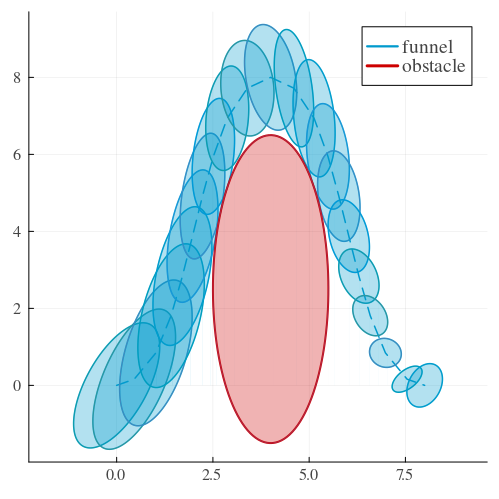

In [26]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom_[:,:,idx],xnom[:,idx],"deepskyblue3",linewidth=1.5,label=label,fill=true)
end
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
display(p2)

In [ ]:
input_proj_funl_node,Rnom = project_onto_input(Qnom,Ynom)

In [ ]:
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[1,:]+input_proj_funl_node[1],color="deepskyblue3",label="")
scatter!(tnom,unom[1,:]-input_proj_funl_node[1],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[2,:]+input_proj_funl_node[2],color="deepskyblue3",label="")
scatter!(tnom,unom[2,:]-input_proj_funl_node[2],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
plot(p1,p2,layout=(1,2),size=(600,200))

# samples

In [ ]:
Q_fit = [[LinearInterpolation(tnom, Qnom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
Y_fit = [[LinearInterpolation(tnom, Ynom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:iu ]
;

In [ ]:
include("./funlopt/funl_utils.jl")

In [ ]:
num_sample = 500
xs_list = []
for i in 1:num_sample
    z = randn(ix)
    z = z / norm(z)
    push!(xs_list,xnom[:,1] + sqrt(Qnom[:,:,1]) * z)
end

In [ ]:
xsam_fwd,tsam,xsam,usam,xnomprop = [],[],[],[],[]
i = 0
for xs in xs_list
    # println(i)
    i += 1
    xf_,ts_,xsam_,usam_,xnom_ = propagate_from_funnel_entry_uncertain_dynamics(xs,
        dynamics,
        xnom,unom,tnom,
        Qnom,Ynom)
    push!(xsam_fwd,xf_)
    push!(tsam,ts_)
    push!(xsam,xsam_)
    push!(usam,usam_)
    push!(xnomprop,xnom_)
end

In [ ]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",label=label)
end
# plot_ellipse(p2,fs.solution.Qi,xnom[:,1],"green3",label="initial and final")
# plot_ellipse(p2,fs.solution.Qf,xnom[:,end],"green3")
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
for x_ in xsam
    plot!(x_[1,:],x_[2,:],color="purple",label=nothing)
end
display(p2)

In [ ]:
# Lyapunov function
Lypsam = []
idx = 1
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    xprop_ = xnomprop[idx]
    Lyp = []
    for iode in 1:length(tsam_)
        t_ = tsam_[iode]
        x_ = xsam_[:,iode]
        xnom_ = xprop_[:,iode]
        Q_ = get_ABF_interp(t_,Q_fit,ix,ix)
        val = (x_ - xnom_)' * inv(Q_) * (x_ - xnom_)
        push!(Lyp,val)
    end
    push!(Lypsam,Lyp)
end


In [ ]:
p3 = Plots.plot(; size=(500,300))
for idx = 1:length(tsam)
    plot!(tsam[idx],Lypsam[idx],c=:purple,label="")
end
plot!(tsam[1],tsam[1]*0 .+ 1.0,c=:red,linestyle=:dash,label="")
display(p3)

In [ ]:
p1 = plot(tsam[1],xnomprop[1][1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[1,:] + sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[1,:] - sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[1,:],color="purple",label="")
end
p2 = plot(tsam[1],xnomprop[1][2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[2,:] + sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[2,:] - sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[2,:],color="purple",label="")
end
p3 = plot(tsam[1],xnomprop[1][3,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[3,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[3,:] + sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[3,:] - sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[3,:],color="purple",label="")
end
plot(p1,p2,p3,layout=(3,1),size=(600,400))

In [ ]:
length_idx = length(tsam)
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[1,:]+input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[1,:]-input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[1,:],color="purple",label="")
end
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[2,:]+input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[2,:]-input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[2,:],color="purple",label="")
end
plot(p1,p2,layout=(1,2),size=(800,400))

In [ ]:
funl_dict = Dict("Q1" => Qnom_, "Y1" => Ynom_, "lam1" => lamnom_, "Q2" => Qnom, "Y2" => Ynom, "lam" => lamnom)

using JLD2, FileIO
@save "./data/funnel_result" funl_dict